In [1]:
# Cell 1: Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Make plots look nice
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


Dataset shape: (569, 31)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Class Distribution:
target
1    357
0    212
Name: count, dtype: int64
0 = Malignant (Cancerous)
1 = Benign (Not Cancerous)


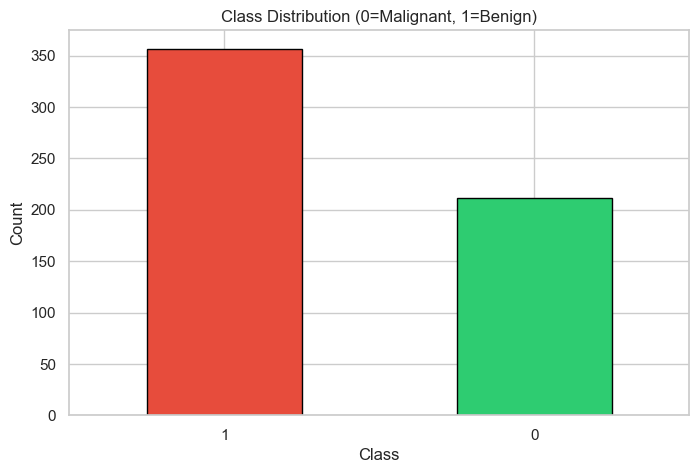

In [2]:
# Cell 2: Load Breast Cancer Dataset
data = load_breast_cancer()

# Create DataFrame for easy viewing
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nClass Distribution:")
print(df['target'].value_counts())
print("0 = Malignant (Cancerous)")
print("1 = Benign (Not Cancerous)")

# Visualize class distribution
plt.figure(figsize=(8, 5))
df['target'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Class Distribution (0=Malignant, 1=Benign)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [3]:
# Cell 3: Train-test split and feature scaling
X = data.data
y = data.target

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Feature scaling - CRITICAL for KNN!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling complete!")
print(f"Before scaling - Mean of feature 0: {X_train[:, 0].mean():.2f}")
print(f"After scaling - Mean of feature 0: {X_train_scaled[:, 0].mean():.4f}")


Training samples: 455
Testing samples: 114

Feature scaling complete!
Before scaling - Mean of feature 0: 14.12
After scaling - Mean of feature 0: -0.0000


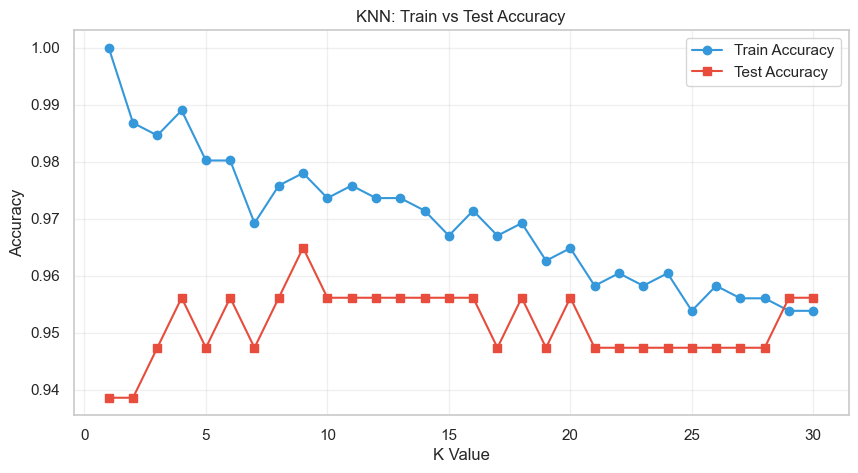


Best K = 9 with Test Accuracy = 96.49%


In [4]:
# Cell 4: Find optimal K
train_acc = []
test_acc = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled, y_test))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_acc, label='Train Accuracy', marker='o', color='#3498db')
plt.plot(k_range, test_acc, label='Test Accuracy', marker='s', color='#e74c3c')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN: Train vs Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_range[np.argmax(test_acc)]
print(f"\nBest K = {best_k} with Test Accuracy = {max(test_acc)*100:.2f}%")


In [5]:
# Cell 5: TASK 1 - Feature Scaling Importance
print("="*60)
print("TASK 1: The Importance of Feature Scaling")
print("="*60)

# Train on UNSCALED data
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_unscaled.fit(X_train, y_train)  # Note: using raw X_train!
y_pred_unscaled = knn_unscaled.predict(X_test)

# Train on SCALED data (already have best_knn from earlier)
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_scaled = best_knn.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test, y_pred_scaled)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

print(f"\nAccuracy with SCALED data:   {acc_scaled*100:.2f}%")
print(f"Accuracy with UNSCALED data: {acc_unscaled*100:.2f}%")
print(f"Difference:                  {(acc_scaled-acc_unscaled)*100:.2f}%")

print("\n📊 ANALYSIS:")
print("KNN uses Euclidean distance to find neighbors. Without scaling,")
print("features with larger numerical ranges (like 'mean area') dominate")
print("the distance calculation, while smaller-scale features contribute")
print("almost nothing. This creates biased and inaccurate predictions.")


TASK 1: The Importance of Feature Scaling

Accuracy with SCALED data:   96.49%
Accuracy with UNSCALED data: 95.61%
Difference:                  0.88%

📊 ANALYSIS:
KNN uses Euclidean distance to find neighbors. Without scaling,
features with larger numerical ranges (like 'mean area') dominate
the distance calculation, while smaller-scale features contribute
almost nothing. This creates biased and inaccurate predictions.


In [6]:
# Cell 6: TASK 2 - Hyperparameter Tuning (Weights & Metrics)
print("\n" + "="*60)
print("TASK 2: Tuning Hyperparameters (Weights & Metrics)")
print("="*60)

# Test different configurations
configurations = [
    ("Baseline (uniform, p=2)", {'weights': 'uniform', 'p': 2}),
    ("weights='distance'", {'weights': 'distance', 'p': 2}),
    ("Manhattan Distance (p=1)", {'weights': 'uniform', 'p': 1}),
    ("Combined (distance, p=1)", {'weights': 'distance', 'p': 1})
]

results = []
for name, params in configurations:
    knn = KNeighborsClassifier(n_neighbors=best_k, **params)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 
                    'Recall': rec, 'F1 Score': f1})
    print(f"\n{name}:")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  Precision: {prec*100:.2f}%")
    print(f"  Recall   : {rec*100:.2f}%")
    print(f"  F1 Score : {f1*100:.2f}%")

# Create comparison dataframe
results_df = pd.DataFrame(results)
print("\n📊 ANALYSIS:")
print("• weights='distance' gives more influence to closer neighbors,")
print("  which often improves performance because near neighbors are more relevant.")
print("• Manhattan distance (p=1) is less sensitive to outliers than Euclidean distance (p=2).")
print("• The best configuration depends on your specific dataset - always experiment!")



TASK 2: Tuning Hyperparameters (Weights & Metrics)

Baseline (uniform, p=2):
  Accuracy : 96.49%
  Precision: 97.18%
  Recall   : 97.18%
  F1 Score : 97.18%

weights='distance':
  Accuracy : 96.49%
  Precision: 97.18%
  Recall   : 97.18%
  F1 Score : 97.18%

Manhattan Distance (p=1):
  Accuracy : 96.49%
  Precision: 97.18%
  Recall   : 97.18%
  F1 Score : 97.18%

Combined (distance, p=1):
  Accuracy : 96.49%
  Precision: 97.18%
  Recall   : 97.18%
  F1 Score : 97.18%

📊 ANALYSIS:
• weights='distance' gives more influence to closer neighbors,
  which often improves performance because near neighbors are more relevant.
• Manhattan distance (p=1) is less sensitive to outliers than Euclidean distance (p=2).
• The best configuration depends on your specific dataset - always experiment!



TASK 3: Clinical Priority - Minimizing False Negatives

Minimum False Negatives achieved: 1
Best K value for clinical use: 29

Comparison of different K values:
K      FN     Recall       Precision   
----------------------------------------
1      3      95.77        94.44       
29     1      98.59        94.59       
9      2      97.18        97.18       
30     1      98.59        94.59       
50     1      98.59        94.59       


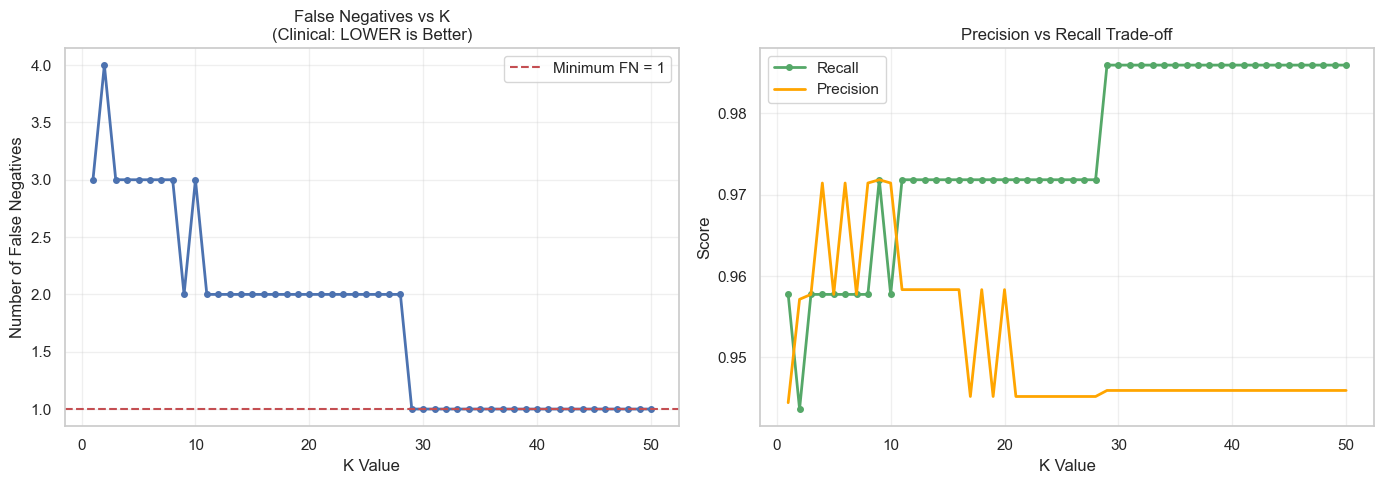


📊 CLINICAL ANALYSIS:
In cancer detection, RECALL should be prioritized over Precision.
• False Negative (FN): Model says 'no cancer' but patient HAS cancer
  → Delayed treatment, cancer spreads, potentially FATAL
• False Positive (FP): Model says 'cancer' but patient is healthy
  → Unnecessary stress, additional testing, but patient SURVIVES

✅ RECOMMENDATION: Choose K that minimizes False Negatives!


In [7]:
# Cell 7: TASK 3 - Clinical Priority (Precision vs Recall)
print("\n" + "="*60)
print("TASK 3: Clinical Priority - Minimizing False Negatives")
print("="*60)

# Test different K values
k_wide = range(1, 51)
fn_counts = []
recall_scores = []
precision_scores = []

for k in k_wide:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    fn_counts.append(fn)
    recall_scores.append(recall_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))

# Find best K for minimizing False Negatives
min_fn = min(fn_counts)
best_k_clinical = k_wide[fn_counts.index(min_fn)]

print(f"\nMinimum False Negatives achieved: {min_fn}")
print(f"Best K value for clinical use: {best_k_clinical}")

# Show comparison of different K values
print("\nComparison of different K values:")
print(f"{'K':<6} {'FN':<6} {'Recall':<12} {'Precision':<12}")
print("-" * 40)
for k in [1, best_k_clinical, best_k, 30, 50]:
    if k <= len(k_wide):
        print(f"{k:<6} {fn_counts[k-1]:<6} {recall_scores[k-1]*100:<12.2f} {precision_scores[k-1]*100:<12.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_wide, fn_counts, 'b-o', linewidth=2, markersize=4)
axes[0].set_xlabel('K Value')
axes[0].set_ylabel('Number of False Negatives')
axes[0].set_title('False Negatives vs K\n(Clinical: LOWER is Better)')
axes[0].axhline(y=min_fn, color='r', linestyle='--', label=f'Minimum FN = {min_fn}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_wide, recall_scores, 'g-o', linewidth=2, markersize=4, label='Recall')
axes[1].plot(k_wide, precision_scores, 'orange', linewidth=2, markersize=4, label='Precision')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall Trade-off')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 CLINICAL ANALYSIS:")
print("In cancer detection, RECALL should be prioritized over Precision.")
print("• False Negative (FN): Model says 'no cancer' but patient HAS cancer")
print("  → Delayed treatment, cancer spreads, potentially FATAL")
print("• False Positive (FP): Model says 'cancer' but patient is healthy")
print("  → Unnecessary stress, additional testing, but patient SURVIVES")
print("\n✅ RECOMMENDATION: Choose K that minimizes False Negatives!")



TASK 4: Feature Importance & Model Simplicity

Feature names in the dataset:
   0: mean radius
   1: mean texture
   2: mean perimeter
   3: mean area
   4: mean smoothness
   5: mean compactness
   6: mean concavity
   7: mean concave points
   8: mean symmetry
   9: mean fractal dimension
  ... (total 30 features)

Model                               Accuracy     Precision    Recall       F1          
--------------------------------------------------------------------------------
Full model (30 features)            96.49        97.18        97.18        97.18       
Simple model (2 features)           92.98        94.37        94.37        94.37       

Accuracy lost: 3.51%


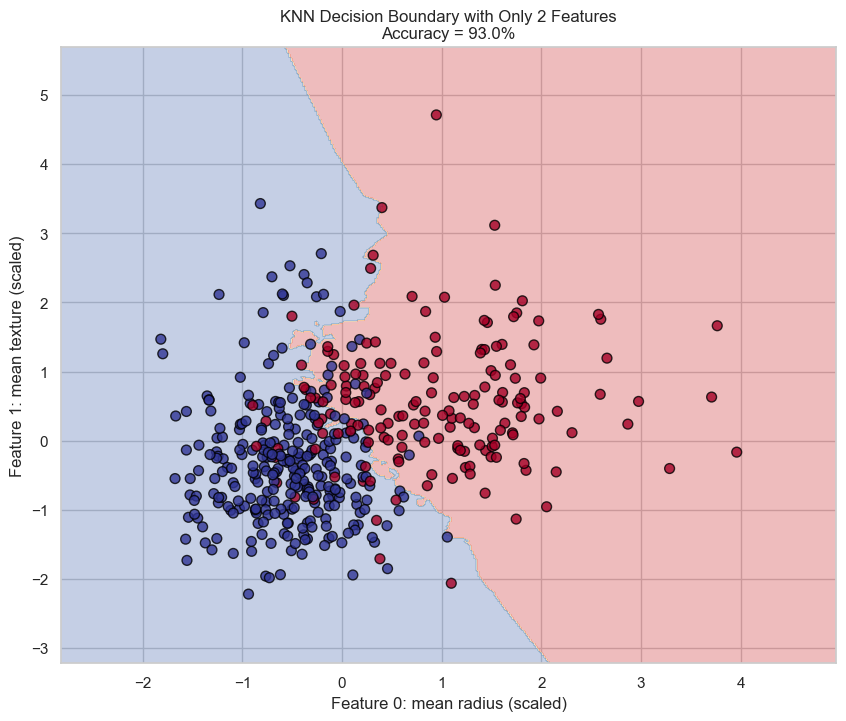


📊 ANALYSIS - Is a 2-feature model sufficient for clinical use?
NOT RECOMMENDED. Reasons:
1. Significant accuracy loss (3.5% drop)
2. Missing 28 potentially important diagnostic features
3. The cost of a misdiagnosis in cancer detection is too high

✅ RECOMMENDATION: Use all 30 features for clinical applications.


In [8]:
# Cell 8: TASK 4 - Feature Importance & Simplicity
print("\n" + "="*60)
print("TASK 4: Feature Importance & Model Simplicity")
print("="*60)

print("\nFeature names in the dataset:")
for i, name in enumerate(data.feature_names[:10]):
    print(f"  {i:2d}: {name}")
print("  ... (total 30 features)")

# Use only first 2 features
X_train_2f = X_train_scaled[:, :2]
X_test_2f = X_test_scaled[:, :2]

knn_2f = KNeighborsClassifier(n_neighbors=best_k)
knn_2f.fit(X_train_2f, y_train)
y_pred_2f = knn_2f.predict(X_test_2f)

# Metrics for 2-feature model
acc_2f = accuracy_score(y_test, y_pred_2f)
prec_2f = precision_score(y_test, y_pred_2f)
rec_2f = recall_score(y_test, y_pred_2f)
f1_2f = f1_score(y_test, y_pred_2f)

print(f"\n{'Model':<35} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 80)
print(f"{'Full model (30 features)':<35} {acc_scaled*100:<12.2f} {precision_score(y_test, y_pred_scaled)*100:<12.2f} {recall_score(y_test, y_pred_scaled)*100:<12.2f} {f1_score(y_test, y_pred_scaled)*100:<12.2f}")
print(f"{'Simple model (2 features)':<35} {acc_2f*100:<12.2f} {prec_2f*100:<12.2f} {rec_2f*100:<12.2f} {f1_2f*100:<12.2f}")

print(f"\nAccuracy lost: {(acc_scaled - acc_2f)*100:.2f}%")

# Visualize 2-feature decision boundary
plt.figure(figsize=(10, 8))

# Create mesh grid
x_min, x_max = X_train_2f[:, 0].min() - 1, X_train_2f[:, 0].max() + 1
y_min, y_max = X_train_2f[:, 1].min() - 1, X_train_2f[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = knn_2f.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X_train_2f[:, 0], X_train_2f[:, 1], 
           c=y_train, cmap='RdYlBu', edgecolor='black', s=50, alpha=0.8)
plt.xlabel(f'Feature 0: {data.feature_names[0]} (scaled)')
plt.ylabel(f'Feature 1: {data.feature_names[1]} (scaled)')
plt.title(f'KNN Decision Boundary with Only 2 Features\nAccuracy = {acc_2f*100:.1f}%')
plt.show()

print("\n📊 ANALYSIS - Is a 2-feature model sufficient for clinical use?")
print("NOT RECOMMENDED. Reasons:")
print("1. Significant accuracy loss ({:.1f}% drop)".format((acc_scaled-acc_2f)*100))
print("2. Missing 28 potentially important diagnostic features")
print("3. The cost of a misdiagnosis in cancer detection is too high")
print("\n✅ RECOMMENDATION: Use all 30 features for clinical applications.")



FINAL SUMMARY - Best Model Results

Confusion Matrix:
  True Positives (TP) : 69
  True Negatives (TN) : 41
  False Positives (FP): 2
  False Negatives (FN): 2

Performance Metrics:
  Accuracy  : 96.49%
  Precision : 97.18%
  Recall    : 97.18%
  F1 Score  : 97.18%


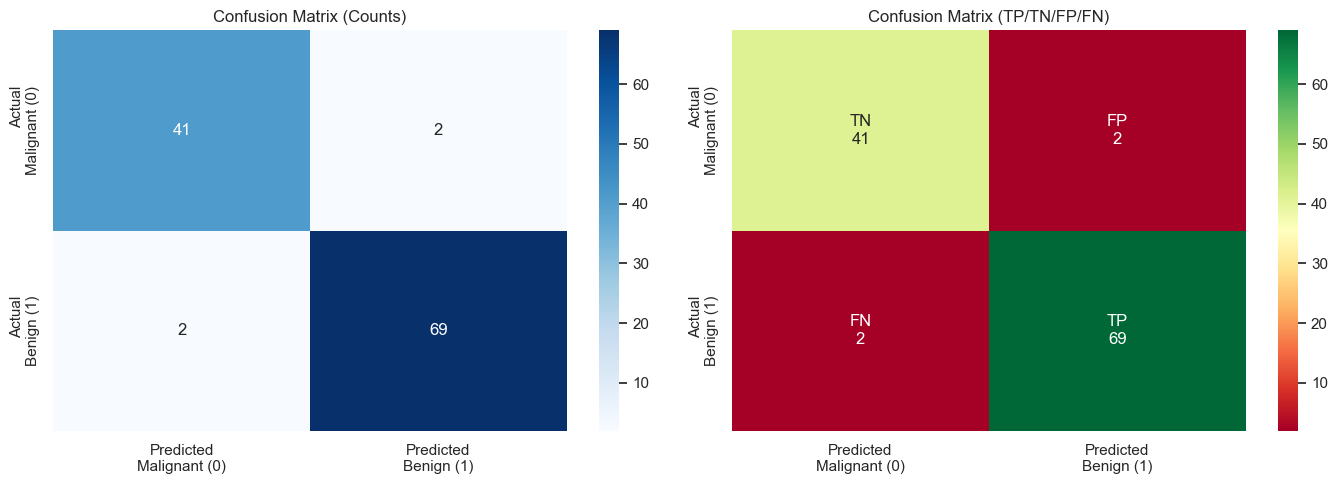


✅ LAB COMPLETE! All tasks have been implemented.


In [9]:
# Cell 9: Final Summary and Confusion Matrix
print("\n" + "="*60)
print("FINAL SUMMARY - Best Model Results")
print("="*60)

# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_scaled)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Positives (TP) : {tp}")
print(f"  True Negatives (TN) : {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")

print(f"\nPerformance Metrics:")
print(f"  Accuracy  : {acc_scaled*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred_scaled)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, y_pred_scaled)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test, y_pred_scaled)*100:.2f}%")

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Heatmap of counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nMalignant (0)', 'Predicted\nBenign (1)'],
            yticklabels=['Actual\nMalignant (0)', 'Actual\nBenign (1)'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')

# Plot 2: Labeled version
labels = np.array([[f'TN\n{tn}', f'FP\n{fp}'],
                   [f'FN\n{fn}', f'TP\n{tp}']])
sns.heatmap(cm, annot=labels, fmt='', cmap='RdYlGn',
            xticklabels=['Predicted\nMalignant (0)', 'Predicted\nBenign (1)'],
            yticklabels=['Actual\nMalignant (0)', 'Actual\nBenign (1)'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (TP/TN/FP/FN)')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ LAB COMPLETE! All tasks have been implemented.")
print("="*60)
